# Web Agent with Memory: Building an Intelligent Website Q&A Agent



Welcome to this hands-on notebook, where you'll learn how to build a web agent that can answer questions by fetching information from websites while also remembering the context of your conversation.

By the end of this notebook you will:

- Understand why memory is crucial for creating intelligent, multi-turn conversations.
- Learn how to scrape web content using Python to provide the agent with information.
- Integrate LangChain's `ConversationBufferMemory` to give your agent a persistent memory.
- See how all the components (user input, agent, tool, website, and memory) work together through a simple architecture diagram.


## 1. Problem Statement and Intuition

Large language models (LLMs) are powerful tools for generating and summarizing text, but they have no built-in awareness of past interactions. When you ask an LLM to find information on a website and then ask a follow-up question, the model doesn't remember what was said previously unless you explicitly provide the full context again.  

Imagine using a chatbot to explore investment opportunities on a website like **E\*TRADE**. You might first ask, ***"Can you show me the top-performing ETFs this month?"*** The bot fetches a list of ETFs. If you then ask, ***"What is the expense ratio of the first ETF?"***, a simple, **stateless** bot would likely fail to understand what **"the first ETF"** refers to, because it has forgotten the previous turn of the conversation.

To fix this, we need to give the agent memory. A simple and effective solution is to record the entire conversation history and feed it back to the model with every new query. LangChain's `ConversationBufferMemory` does exactly this: it stores the entire conversation history in memory without any additional processing. When we ask a follow-up question, the agent can include the full chat history in its prompt, so the model knows exactly what we’re talking about.


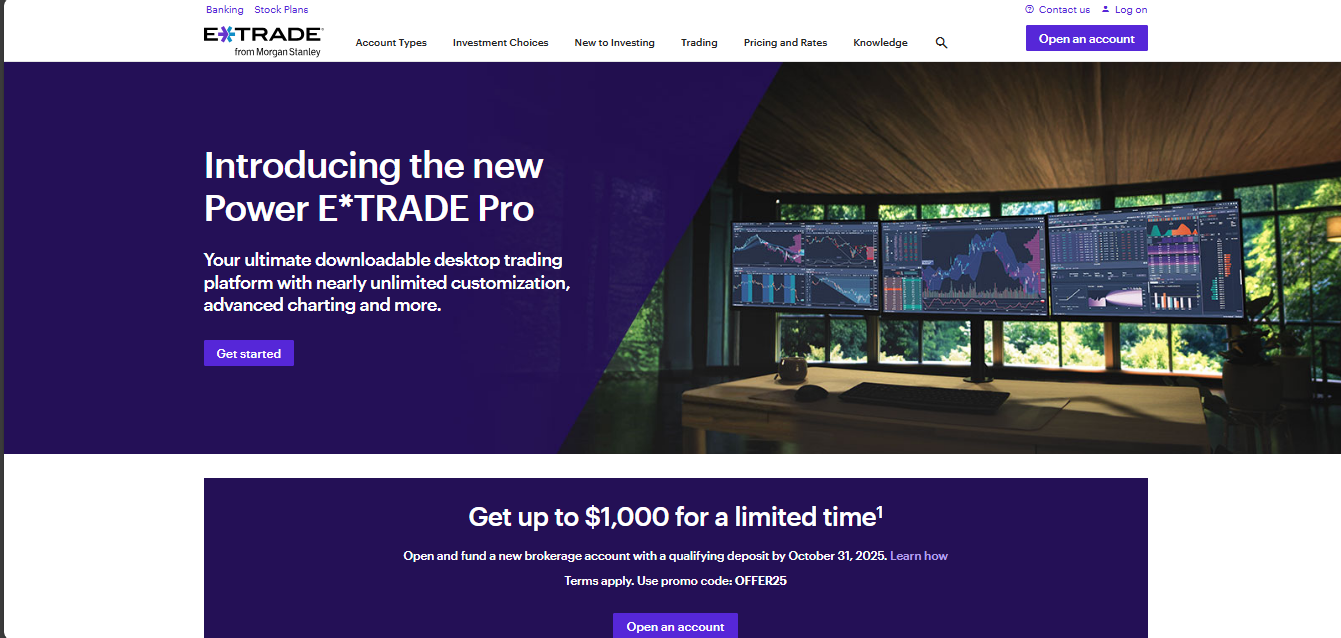


For this project, we’ll demonstrate the support bot using publicly available content from E\*TRADE — E\*TRADE is an online trading platform in the US that lets people invest in stocks, ETFs, options, and retirement accounts.
It’s popular with both beginners and active traders for managing investments digitally. This makes it an ideal example to build and test our Web Agent with Memory.


In the next sections we’ll build this memory‑augmented web agent in 8 steps.


<center><img src = "https://substackcdn.com/image/fetch/$s_!A_Oy!,f_auto,q_auto:good,fl_progressive:steep/https%3A%2F%2Fsubstack-post-media.s3.amazonaws.com%2Fpublic%2Fimages%2Fc3177e12-432e-4e41-814f-6febf7a35f68_1360x972.png" width = 500 align = "center"></center>

## 1. Setting up the Environment

Before we can build our agent, we need to install and import the right tools. We'll be using **LangChain**, a framework for building LLM applications, along with a few supporting libraries:

- `langchain_community`: provides community‑maintained tools and integrations.
- `requests` and `BeautifulSoup`: to download and parse web pages.
- `google.colab.userdata` or `getpass`: to load your OpenAI API key securely.

Let's start by installing the required packages.


In this step you set up dependencies and import what you need:


*   `requests` + `BeautifulSoup` → to fetch and parse web pages
*   `langchain` core/agents/memory → to build the agent & add memory
OpenAI chat model wrapper → for LLM responses

**Why we need this**

Without a parser, the agent can't read websites; without memory, it can't do follow‑ups; without the LLM, it can't reason or answer.

In [ ]:
# Step 1 – Install the required packages
# LangChain 1.x split things into multiple packages, so we install them all.
# - langchain: core framework
# - langchain-openai: OpenAI chat models (ChatOpenAI moved here)
# - langchain-community: community tools/integrations
# - langgraph: replaces initialize_agent with create_react_agent
!pip install -q langchain langchain-openai langchain-community langgraph

After running the above cell, you’ll see installation logs from `pip`. These commands install the libraries we need. If the packages are already installed you may see messages indicating that they're up to date.


### Importing the necessary modules

Next, we import Python modules that will power our agent. Each import serves a specific purpose:

- `os` and `getpass` – for loading your OpenAI API key securely.
- `requests` and `BeautifulSoup` – for fetching and parsing website content.
- LangChain components:
  - `initialize_agent`, `Tool` and `AgentType` – to build our agent.
  - `ChatOpenAI` – the chat model wrapper for OpenAI’s API.
  - `ConversationBufferMemory` – memory that records the entire conversation.

We’ll import these modules now.


In [ ]:
# Import the necessary modules

# Operating system interactions (used for environment variables)
import os
# Securely prompt for your API key in an interactive environment
import getpass
from google.colab import userdata

# Web scraping utilities
import requests
from bs4 import BeautifulSoup

# LangChain 1.x imports — the old paths have been reorganized:
# - ChatOpenAI moved from langchain.chat_models to langchain_openai
# - Tool moved to langchain_core.tools
# - initialize_agent / AgentType are REMOVED; use create_react_agent from langgraph instead
# - ConversationBufferMemory is replaced by MemorySaver (a checkpointer) in langgraph
from langchain_openai import ChatOpenAI
from langchain_core.tools import Tool
from langchain_core.messages import HumanMessage
from langgraph.prebuilt import create_react_agent
from langgraph.checkpoint.memory import MemorySaver

Great! With the imports complete, we have access to everything we need to build the agent. Notice how we separate responsibilities: web scraping tools handle website content, while LangChain components handle the LLM and agent logic.


### 2. Loading your OpenAI API key

To interact with OpenAI’s GPT models, you’ll need an API key. Never hard‑code your key directly in your code for security reasons. Instead, read it from a secure input (e.g., `getpass`) or from an environment variable.  

In the code cell below, we first try to retrieve your key from an environment variable called `OPENAI_API_KEY`. If it’s not set, we fall back to prompting you to enter it manually. Feel free to adapt this to your environment.


In [ ]:
# Step 2 – Load the OpenAI API key

# Prefer an already-set environment variable
api_key = os.environ.get('OPENAI_API_KEY')

# In Colab, try pulling from the Colab Secrets manager (the "openai" secret)
if not api_key:
    try:
        api_key = userdata.get('openai')
    except Exception:
        api_key = None

# Final fallback: prompt the user (hidden input)
if not api_key:
    api_key = getpass.getpass('Enter your OpenAI API key: ')

# Make it visible to LangChain / OpenAI SDK
os.environ["OPENAI_API_KEY"] = api_key

Enter your OpenAI API key: ··········


Now that your API key is loaded, we can start creating the logic for extracting website text and building our agent.


## 3. Extracting Text from a Website

Before the agent can answer questions about a webpage, it needs to **extract the text** from that page. We'll create a small helper function to do this using `requests` to download the page and `BeautifulSoup` to parse the HTML.  

Why is this important? Most websites contain a lot of HTML tags, scripts and styling that we don't care about. We just need the readable text that describes the content of the page. Our function will:

1. **Send an HTTP GET request** to the given URL.
2. **Parse the HTML** into a structured format using BeautifulSoup.
3. **Extract the visible text** using `.get_text()` so we have plain content to feed into the LLM.

Let's implement this helper function now.


</center><img src = "https://stackabuse.s3.amazonaws.com/media/parsing-html-with-beautifulsoup-in-python-1.jpg" align = "center"></img></center>

In [ ]:
# Step 3.1 – Define a function to extract text from a URL

def extract_website_text(url):
    # Send an HTTP GET request to the website
    response = requests.get(url)
    # Parse the response content with BeautifulSoup
    soup = BeautifulSoup(response.text, 'html.parser')
    # Extract and return all the visible text
    return soup.get_text()


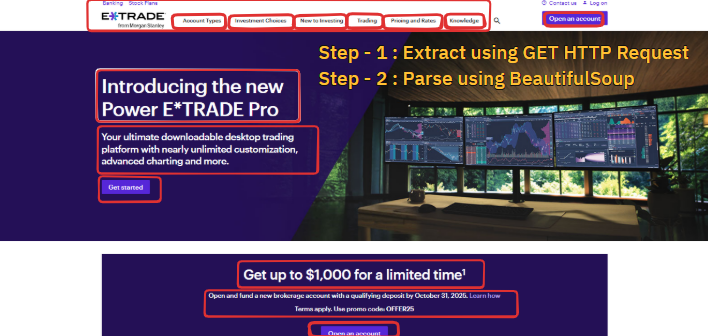

This function is deliberately simple: it grabs the entire text of the page. In a production system you might want to filter out irrelevant sections (navigation links, ads, etc.) or limit the length of the extracted text to fit within the model's context window.


## 4. Building the Website Q&A Tool and Memory

Our agent will need to do two things:

1. **Fetch and answer questions using website content** when the user supplies a URL.
2. **Recall previous answers** and respond to follow‑up questions using conversation history.

We'll write a function called `website_qa_tool` that distinguishes between these two modes. The input format we'll use is `<website URL> | <question>`.  

- If the input includes a pipe (`|`), we split it into the URL and the question. We fetch the website content via the `extract_website_text` function and construct a prompt combining the question and the content.  
- Otherwise (no pipe), we assume the user is asking a follow‑up question. We load the chat history from the memory and include it in the prompt so the model knows what we've already discussed.  

Behind the scenes we'll use **LangChain's `ConversationBufferMemory`** to store chat history. Remember: this memory *simply stores the entire conversation history*, so we can retrieve it later.


<center><img src = "https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcScZm5d6M-AF_5uZ6MT5ZijElCWhX-K8SThpg&s" width = 500 align = "center"></center>

In [ ]:
# Step 4.1 – Define the processing function for the tool

def website_qa_tool(input_text: str) -> str:
    '''Answer a user's question using website content.

    Input format:
    - "<url> | <question>"  → fetch the URL and answer using its content
    - "<question>"          → answer directly (the agent's own memory handles follow-ups
                               via the thread_id, so we no longer need to read memory here)

    Returns:
        The model's answer as a string.
    '''
    # Instantiate the LLM once per call (cheap, and avoids stale references)
    llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)

    # Case 1: URL + question, ignore agent placeholders like "<website URL>"
    if '|' in input_text and "<website URL>" not in input_text:
        url, question = input_text.split('|', 1)
        content = extract_website_text(url.strip())
        prompt = (
            f"Answer this question using the content from the website:\n\n"
            f"{question.strip()}\n\nContent:\n{content[:6000]}"
        )
    else:
        # Case 2: just a question — strip placeholder if the agent emitted one
        if "<website URL>" in input_text and "|" in input_text:
            _, question = input_text.split('|', 1)
            input_text = question.strip()
        prompt = f"Answer the user's question as best you can.\n\nQuestion:\n{input_text}"

    # .predict() is deprecated in LangChain 1.x; use .invoke() which returns a message object
    response = llm.invoke(prompt)
    return response.content


# Step 4.2 – Create the tool using LangChain's Tool class
# (Tool itself still exists, just imported from langchain_core.tools now)
web_tool = Tool(
    name="WebsiteQnA",
    func=website_qa_tool,
    description=(
        "If input is '<website URL> | <question>' → fetch from website, or "
        "if input is '<question>' → answer using chat history."
    ),
)

# Step 4.3 – Set up memory
# ConversationBufferMemory is GONE in LangChain 1.x. LangGraph agents use a
# checkpointer (MemorySaver = in-memory store) combined with a thread_id to
# persist conversation history automatically across .invoke() calls.
memory = MemorySaver()

The `website_qa_tool` function encapsulates the logic of deciding whether to fetch new content or to rely on the stored chat history. We then package this function into a `Tool` that our agent can call, and create a `ConversationBufferMemory` instance to remember past exchanges.


## 5. Initialising the Agent

Now that we have a tool and a memory, we can assemble our agent. LangChain’s `initialize_agent` function wires up multiple tools with a language model to form a full agent. We’ll use the `ZERO_SHOT_REACT_DESCRIPTION` agent type, which allows the agent to decide when to call tools based on the instructions we provide.  

The key components in the call below are:

- `tools=[web_tool]`: a list containing the single tool we created.
- `llm=ChatOpenAI()`: the chat model we'll use for natural language processing.
- `agent=AgentType.ZERO_SHOT_REACT_DESCRIPTION`: this agent type uses zero‑shot reasoning to decide which tool to use.
- `memory=memory`: we supply our `ConversationBufferMemory` so that the agent retains conversation history.
- `verbose=True`: prints intermediate reasoning steps, useful for debugging.
- `handle_parsing_errors=True`: helps the agent recover gracefully if the model outputs something unexpected.

Let's initialise the agent now.


In [ ]:
# Step 5.1 – Initialise the agent with our tool and memory

# create_react_agent is the LangGraph replacement for initialize_agent.
# It builds a ReAct-style (reason + act) agent as a compiled graph.
# - model:        the LLM that drives the agent
# - tools:        list of tools the agent can call
# - checkpointer: where conversation state is saved (replaces the old `memory=` arg)
agent = create_react_agent(
    model=ChatOpenAI(model="gpt-4o-mini", temperature=0),
    tools=[web_tool],
    checkpointer=memory,
)

/tmp/ipykernel_24823/1600610949.py:8: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  agent = create_react_agent(


After running the above cell the agent is ready! In verbose mode you’ll see intermediate steps whenever the agent reasons about using a tool.


## 6. Running the Agent & Experiencing the Memory

Let’s put our agent to the test. We’ll ask it a question about a website and then follow up with another question that depends on the previous answer.  

For example, we'll use the `https://us.etrade.com` homepage. First, we'll ask:

> *“Can you tell me what this website offers to beginner investors?”*

The agent will fetch the website content, find relevant information and answer. Then we’ll ask follow-up questions

Thanks to the `ConversationBufferMemory`, the agent will remember the previous answer and understand that "the course" refers to the machine learning course we just discussed.

Let's see it in action.


<center><img src = "https://docs.aws.amazon.com/images/prescriptive-guidance/latest/agentic-ai-patterns/images/memory-augmented-agents.png" align = "center" width = 700></center>

In [ ]:
# Step 6.1 – Ask the initial question using the URL and pipe separator

# The thread_id groups messages into one conversation. Reuse the same id for follow-ups
# so the agent remembers what was said before (this is how memory works in LangGraph).
config = {"configurable": {"thread_id": "etrade-demo"}}

response = agent.invoke(
    {"messages": [HumanMessage(content="https://us.etrade.com | Can you tell me what this website offers to beginner investors?")]},
    config=config,
)
# The final answer is the last message in the returned messages list
print(response["messages"][-1].content)

The E*TRADE website offers several resources and tools specifically designed for beginner investors, including:

1. **Account Types**: A variety of account options tailored to different financial goals, making it easier for beginners to choose the right one.

2. **Educational Resources**: Access to educational materials that help beginners learn about trading, investing, and retirement planning.

3. **Planning Tools**: Tools to help users calculate, estimate, and build their investment strategies, which is particularly useful for those just starting out.

4. **Automated Investing**: Solutions that use digital technology to build and manage portfolios for beginners who may feel overwhelmed by managing investments.

5. **Expert Insights**: Access to expert research and insights from Morgan Stanley, including real-time market news and analyst reports to help understand market trends.

6. **Customer Support**: Customer service and support options, including FAQs and contact options, to ass

In [ ]:
# Step 6.2 – Ask a follow-up question using the stored conversation
# Same thread_id = agent sees the full prior exchange and can answer contextually
response = agent.invoke(
    {"messages": [HumanMessage(content="Can you explain more about investment accounts on this website?")]},
    config=config,
)
print(response["messages"][-1].content)

E*TRADE offers a variety of investment accounts designed to meet different financial goals. Here’s a breakdown of the main types of accounts available:

1. **Brokerage Accounts**: Ideal for individuals looking to trade a wide range of assets, including stocks, options, mutual funds, ETFs, futures, bonds, and cryptocurrencies. These accounts provide flexibility for both aspiring and experienced investors.

2. **Banking Accounts**: Through Morgan Stanley Private Bank, E*TRADE offers banking solutions, including:
   - **Premium Savings Account**: Competitive interest rates.
   - **Max-Rate Checking**: A checking account with enhanced interest rates.
   - **Certificates of Deposit (CDs)**: Fixed-term savings options.
   - **Line of Credit**: Access to credit as needed.

3. **Retirement Accounts**: Tailored for long-term savings and investment for retirement, helping individuals plan for their financial future.

E*TRADE also provides powerful trading platforms, including the standard E*TRAD

In [ ]:
# Step 6.2 – Another follow-up from the same conversation thread
response = agent.invoke(
    {"messages": [HumanMessage(content="Based on what you told me earlier, what kinds of trading options are available for active traders on this website?")]},
    config=config,
)
print(response["messages"][-1].content)

Active traders on E*TRADE have access to a variety of trading options, including:

1. **Stocks**: Trade shares of publicly listed companies.
2. **Options**: Engage in options trading for more strategic investment opportunities.
3. **Mutual Funds**: Invest in professionally managed mutual funds.
4. **ETFs (Exchange-Traded Funds)**: Trade ETFs that track various indices or sectors.
5. **Futures**: Participate in futures trading for commodities and financial instruments.
6. **Bonds**: Invest in fixed-income securities.
7. **Cryptocurrency**: Trade various cryptocurrencies.

Active traders can also utilize the **Power E*TRADE Platform**, which is designed specifically for advanced trading strategies and tools, providing a robust environment for executing trades efficiently.


When you run the above cell, the first call will trigger the website content extraction and answer your question. The second call will show the magic of memory: instead of fetching the site again, the agent will use the chat history stored in `memory` to understand what "the course" refers to and provide a coherent answer. Try experimenting with your own websites and follow‑up questions!


## 7. Visualising the Agent Architecture

To better understand how the pieces fit together, here's a simple diagram illustrating the flow of data in our web agent with memory:

<center><img src = "https://media.licdn.com/dms/image/v2/D5612AQECPwrJGDG6YQ/article-cover_image-shrink_720_1280/article-cover_image-shrink_720_1280/0/1709529345065?e=2147483647&v=beta&t=5YY5Tr677j9krwGzGf26NBwDQM9Td6XauTcu6b-yybo"></img></center>

1. **User Input**: You provide either `<URL> | <question>` or just a follow‑up question.  
2. **Agent**: Interprets your input and decides whether to call a tool.  
3. **WebsiteQnA Tool**: If a URL is provided, the tool scrapes the website and formulates a prompt. If not, it retrieves the chat history from **Memory**.  
4. **Memory (ConversationBufferMemory)**: Stores the entire conversation for later use.  
5. **LLM (ChatOpenAI)**: Generates the answer based on the prompt and context.

This visual representation should help you (and anyone you teach!) explain the data flow clearly.


**Applications of this approach** extend well beyond demo chatbots:

- **Customer support**: remembering a user’s previous issues, suggested fixes and preferences.
- **Education**: tutoring systems that track what a learner has already studied and which questions were answered.
- **Research assistants**: agents that gather information from multiple sites while keeping a persistent context of your goals.

## 8. Summary

In this notebook, you learned how to build a simple yet powerful web agent that can answer questions about webpages **and** remember your conversation. Here's a recap of what we accomplished:

- **Problem solved**: Overcame the forgetfulness of naive chatbots by adding a conversational memory.
- **Web scraping**: Used `requests` and `BeautifulSoup` to extract text from websites.
- **LangChain tools**: Created a custom Q&A tool and wrapped it in a `Tool` object.
- **Memory**: Leveraged `ConversationBufferMemory` to store and retrieve chat history.
- **Agent**: Combined the tool, memory and chat model using `initialize_agent` with the `ZERO_SHOT_REACT_DESCRIPTION` agent type.